## Connect to the database

In [30]:
import sqlite3

conn = sqlite3.connect("Chinook_Sqlite.sqlite")
print("Connected Successfully!")

Connected Successfully!


## Check all tables

In [31]:
import pandas as pd

query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

tables = pd.read_sql(query, conn)
print(tables)

             name
0           Album
1          Artist
2        Customer
3        Employee
4           Genre
5         Invoice
6     InvoiceLine
7       MediaType
8        Playlist
9   PlaylistTrack
10          Track


## Preview the Data

In [32]:
tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table';
""", conn)

for table in tables["name"]:
    print("\n" + "="*70)
    print(f"TABLE: {table}")
    print("="*70)

    print("\nSchema:")
    display(pd.read_sql(f"PRAGMA table_info({table});", conn))

    print("\nSample Data:")
    display(pd.read_sql(f"SELECT * FROM {table} LIMIT 5;", conn))


TABLE: Album

Schema:


,cid,name,type,notnull,dflt_value,pk
0,0,AlbumId,INTEGER,1,None,1
1,1,Title,NVARCHAR(160),1,None,0
2,2,ArtistId,INTEGER,1,None,0



Sample Data:


,AlbumId,Title,ArtistId
0,1,For Those About To Rock We Salute You,1
1,2,Balls to the Wall,2
2,3,Restless and Wild,2
3,4,Let There Be Rock,1
4,5,Big Ones,3



TABLE: Artist

Schema:


...

,PlaylistId,TrackId
0,1,3402
1,1,3389
2,1,3390
3,1,3391
4,1,3392



TABLE: Track

Schema:


,cid,name,type,notnull,dflt_value,pk
0,0,TrackId,INTEGER,1,None,1
1,1,Name,NVARCHAR(200),1,None,0
2,2,AlbumId,INTEGER,0,None,0
3,3,MediaTypeId,INTEGER,1,None,0
4,4,GenreId,INTEGER,0,None,0
5,5,Composer,NVARCHAR(220),0,None,0
6,6,Milliseconds,INTEGER,1,None,0
7,7,Bytes,INTEGER,0,None,0
8,8,UnitPrice,"NUMERIC(10,2)",1,None,0



Sample Data:


,TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
0,1,For Those About To Rock (We Salute You),1,1,1,"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99
1,2,Balls to the Wall,2,2,1,"U. Dirkschneider, W. Hoffmann, H. Frank, P. Ba...",342562,5510424,0.99
2,3,Fast As a Shark,3,2,1,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",230619,3990994,0.99
3,4,Restless and Wild,3,2,1,"F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. D...",252051,4331779,0.99
4,5,Princess of the Dawn,3,2,1,Deaffy & R.A. Smith-Diesel,375418,6290521,0.99


# Database Schema and Relationships

The Chinook database is a relational SQLite database representing a digital music store. The tables are connected using **Primary Keys (PK)** and **Foreign Keys (FK)**.

## Main Relationships

### 1. Customer → Invoice
- **Primary Key:** `Customer.CustomerId`
- **Foreign Key:** `Invoice.CustomerId`

Each customer can have multiple invoices, but each invoice belongs to only one customer.

```
Customer (1)
    │
    └── CustomerId
           │
           ▼
Invoice (Many)
```

---

### 2. Invoice → InvoiceLine
- **Primary Key:** `Invoice.InvoiceId`
- **Foreign Key:** `InvoiceLine.InvoiceId`

Each invoice can contain multiple purchased tracks.

```
Invoice (1)
    │
    └── InvoiceId
           │
           ▼
InvoiceLine (Many)
```

---

### 3. Track → InvoiceLine
- **Primary Key:** `Track.TrackId`
- **Foreign Key:** `InvoiceLine.TrackId`

Each invoice line represents one purchased track.

```
Track (1)
    │
    └── TrackId
           │
           ▼
InvoiceLine (Many)
```

---

### 4. Album → Track
- **Primary Key:** `Album.AlbumId`
- **Foreign Key:** `Track.AlbumId`

An album can contain multiple tracks.

```
Album (1)
    │
    └── AlbumId
           │
           ▼
Track (Many)
```

---

### 5. Artist → Album
- **Primary Key:** `Artist.ArtistId`
- **Foreign Key:** `Album.ArtistId`

An artist can have multiple albums.

```
Artist (1)
    │
    └── ArtistId
           │
           ▼
Album (Many)
```

---

### 6. Employee → Customer
- **Primary Key:** `Employee.EmployeeId`
- **Foreign Key:** `Customer.SupportRepId`

Each employee supports multiple customers.

```
Employee (1)
    │
    └── EmployeeId
           │
           ▼
Customer (Many)
```

---

## Query 1: Top 10 best-selling tracks

In [41]:
query = """
SELECT
    Track.Name,
    SUM(InvoiceLine.Quantity) AS TotalSold
FROM Track
JOIN InvoiceLine
ON Track.TrackId = InvoiceLine.TrackId
GROUP BY Track.Name
ORDER BY TotalSold DESC
LIMIT 10;
"""

top_tracks = pd.read_sql(query, conn)

top_tracks

,Name,TotalSold
0,The Trooper,5
1,Untitled,4
2,The Number Of The Beast,4
3,Sure Know Something,4
4,Hallowed Be Thy Name,4
5,Eruption,4
6,Where Eagles Dare,3
7,Welcome Home (Sanitarium),3
8,Sweetest Thing,3
9,Surrender,3


## Query 2: Country with the highest revenue

In [42]:
query = """
SELECT
    c.Country,
    SUM(i.Total) AS Revenue
FROM Customer c
JOIN Invoice i
ON c.CustomerId = i.CustomerId
GROUP BY c.Country
ORDER BY Revenue DESC;
"""

country_revenue = pd.read_sql(query, conn)

display(country_revenue)

,Country,Revenue
0,USA,523.06
1,Canada,303.96
2,France,195.10
3,Brazil,190.10
4,Germany,156.48
5,United Kingdom,112.86
6,Czech Republic,90.24
7,Portugal,77.24
8,India,75.26
9,Chile,46.62


## Query 3: Top-performing sales employee

In [43]:
query = """
SELECT
    e.FirstName || ' ' || e.LastName AS Employee,
    SUM(i.Total) AS TotalRevenue
FROM Employee e
JOIN Customer c
ON e.EmployeeId = c.SupportRepId
JOIN Invoice i
ON c.CustomerId = i.CustomerId
GROUP BY e.EmployeeId
ORDER BY TotalRevenue DESC;
"""

employee_sales = pd.read_sql(query, conn)

display(employee_sales)

,Employee,TotalRevenue
0,Jane Peacock,833.04
1,Margaret Park,775.40
2,Steve Johnson,720.16


### Visualization of Queries

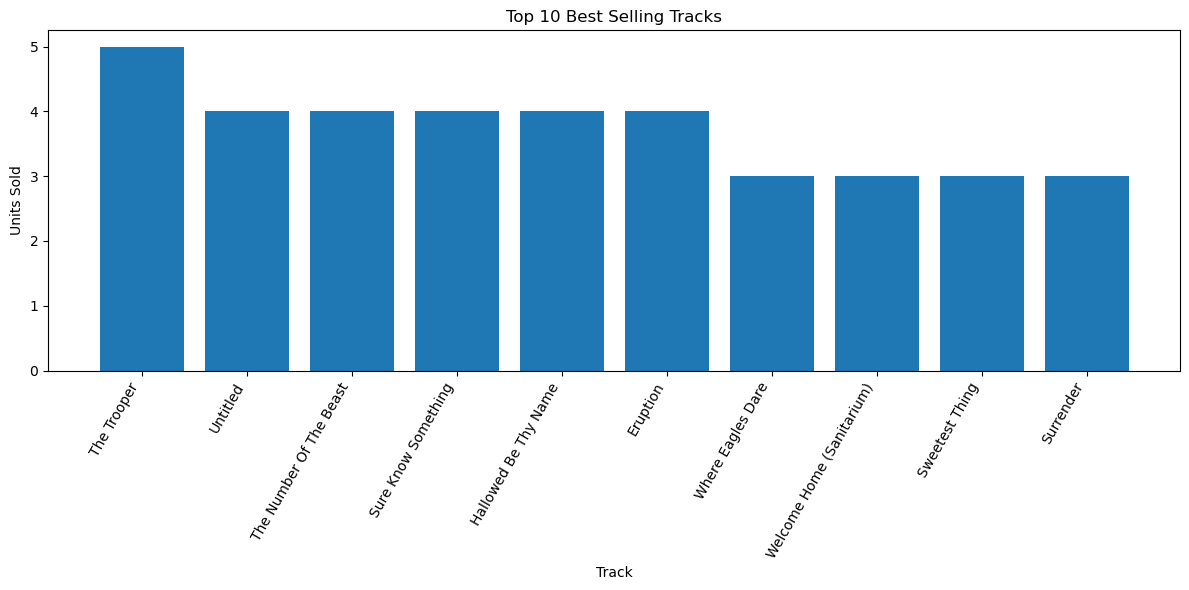

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(top_tracks["Name"], top_tracks["TotalSold"])

plt.xticks(rotation=60, ha='right')

plt.title("Top 10 Best Selling Tracks")

plt.xlabel("Track")

plt.ylabel("Units Sold")

plt.tight_layout()

plt.show()

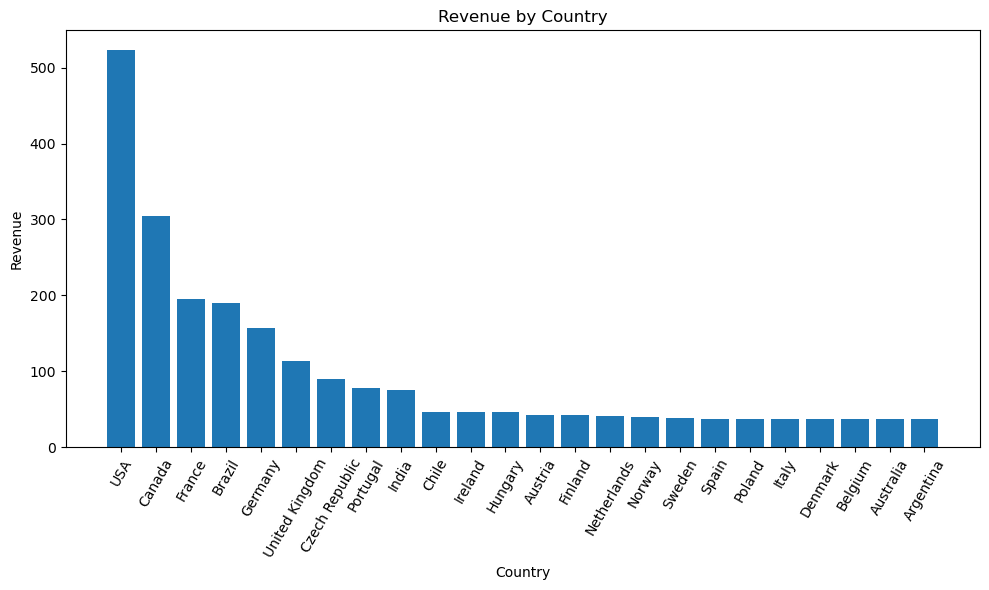

In [45]:
plt.figure(figsize=(10,6))

plt.bar(country_revenue["Country"], country_revenue["Revenue"])

plt.xticks(rotation=60)

plt.title("Revenue by Country")

plt.xlabel("Country")

plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

## Overall Database Relationship

```
Artist
   │
   ▼
Album
   │
   ▼
Track
   │
   ▼
InvoiceLine
   ▲
   │
Invoice
   ▲
   │
Customer
   ▲
   │
Employee
```

## Summary

- A customer places one or more invoices.
- Each invoice contains one or more purchased tracks through the `InvoiceLine` table.
- Every track belongs to an album.
- Every album belongs to an artist.
- Every customer is assigned to a support representative (employee).

These relationships enable analysis of customer purchases, music sales, employee performance, and revenue generation across the Chinook database.